# Week 1 — the frontier of Wikipedia's Marvel universe

**Varmel · 02805 Social Graphs and Interactions · DTU**

Everybody looks at the centre of this network. This notebook goes the other way: to
the 17 characters with no links at all, the island of 9 that never speaks to anyone,
and the 18 held on by a single thread.

The question: **what does it take to be inside Wikipedia's Marvel universe?**

Every number in [`posts/week1.html`](../../posts/week1.html) is computed here or in
`analysis_week1.py`, which this notebook imports so the two can never disagree.

## 1. Load the snapshot — roster first

The one trap the course flags: build the graph from the edge list alone and the 17
characters with no link in either direction disappear silently. `n` would be 286 and
nothing would tell you. They are exactly the population this notebook is about, so the
node roster goes in first.

In [1]:
import analysis_week1 as A     # the same module the post is built from

G, U = A.G, A.U
print("nodes", G.number_of_nodes(), "  edges", G.number_of_edges())
print("isolates kept:", sum(1 for n in G if G.degree(n) == 0))

nodes 303   edges 1784
isolates kept: 17


In [2]:
A.report()

n=303  directed edges=1784  undirected pairs=1434 (350 of them reciprocal)
directed:   density=0.0195  mean in-degree=5.89
undirected: density=0.0313  <k>=9.47
components=19  giant=277  island=9 (22 internal links)  isolates=17
pendants=18: 15 only link out, 1 is only linked to, 2 go both ways
reciprocity=0.392   degree<=3: 92 characters


## 2. Nineteen components

One continent, one island, seventeen people in the water. What is striking is what is
*missing*: there is no archipelago. No cluster of three, no pair holding hands. You are
either inside the universe or entirely outside it.

In [3]:
sizes = [len(c) for c in A.comps]
print("components:", len(A.comps))
print("sizes:", sizes)
print("\ngiant:", len(A.giant), "  island:", len(A.island), "  isolates:", len(A.isolates))

components: 19
sizes: [277, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

giant: 277   island: 9   isolates: 17


## 3. The island: nine characters who only talk to each other

All nine come from *Strikeforce: Morituri* (1986–89), a series set in its own
continuity. Internally they are denser than the network at large; externally they do
not exist.

In [4]:
import pandas as pd

pd.DataFrame([(A.NAME[n], A.deg_in[n], A.deg_out[n]) for n in A.island],
             columns=["character", "in", "out"])

,character,in,out
0,Backhand (character),2,1
1,Blackthorn (character),2,1
2,Radian (Morituri),4,6
3,Scaredycat,3,3
4,Scatterbrain (Morituri),2,2
5,Shear (character),1,2
6,Snapdragon (Morituri),2,3
7,Toxyn,3,2
8,Vyking,3,2


In [5]:
sub = G.subgraph(A.island)
print("island: %d characters, %d internal links, density %.3f"
      % (sub.number_of_nodes(), sub.number_of_edges(), A.nx.density(sub)))
print("whole network density: %.3f" % A.nx.density(G))

island: 9 characters, 22 internal links, density 0.306
whole network density: 0.019


### Are they just stubs?

The rival explanation is that these articles contain no links at all. The wiki-source
says otherwise — they link out plenty, to the series, the writers, the publisher. The
last column is the finding.

In [6]:
A.island_looks_outward()


the island's articles do link out - just never off the island
     article  [[links]] in source  to island peers  to anyone else in the roster
    Backhand                   21                1                             0
  Blackthorn                   28                1                             0
      Radian                   76                6                             0
  Scaredycat                   25                3                             0
Scatterbrain                   27                2                             0
       Shear                   27                2                             0
  Snapdragon                   25                3                             0
       Toxyn                   22                2                             0
      Vyking                   28                2                             0


,article,[[links]] in source,to island peers,to anyone else in the roster
0,Backhand,21,1,0
1,Blackthorn,28,1,0
2,Radian,76,6,0
3,Scaredycat,25,3,0
4,Scatterbrain,27,2,0
5,Shear,27,2,0
6,Snapdragon,25,3,0
7,Toxyn,22,2,0
8,Vyking,28,2,0


## 4. The seventeen castaways are four different things

They have nothing in common as characters. Read the opening sentence of each article
and they sort themselves by *how they got into the category*: another publisher,
another medium, another era. Being isolated is not the same as being minor — Baymax
headlines a Disney film.

In [7]:
for n in A.isolates:
    print("%-30s %s" % (A.NAME[n], str(A.DESC[n])[:88]))

Baymax                         Baymax is a fictional superhero character appearing in American comic books published by
Bird-Brain (Marvel Comics)     Bird-Brain is a character appearing in American comic books published by Marvel Comics, 
Black Fox (Robert Paine)       Black Fox (Dr. Robert William Paine) is a fictional superhero appearing in American comi
Brain Drain (character)        Brain Drain (Werner Schmidt) is a character appearing in American comic books published 
Breeze Barton                  Breeze Barton is a fictional character appearing in American comic books published by Ma
Captain Midlands               Captain Midlands (Sid Ridley) is a fictional character appearing in American comic books
Charcoal (comics)              Charcoal (Charlie Burlingame) is a fictional character appearing in American comic books
Father Time (Marvel Comics)    Father Time (Larry Scott) is a superhero appearing in American comic books published by 
Happy Sam Sawyer               Samuel Sa

## 5. The objection that almost wins

"They are stubs." That is a real explanation, so we tested it against the byte size of
all 303 articles (`prop=info`, 50 titles per request, cached on disk).

It is largely right — and then two castaways refuse to fit.

In [8]:
sizes_df = A.length_frame()
stats = A.length_stats(sizes_df)
A.size_residuals(sizes_df);


article size (kB): castaways median 6.7, everyone else 17.4
  overlap: 2 of 17 castaways are bigger than the median connected article


  spearman(size, degree) over the whole roster: 0.822

castaways too big to be dismissed as stubs:
  Miracleman                  62 kB, degree 0
  Baymax                      24 kB, degree 0
  connected articles of 20-70 kB: median degree 11 (n=91)


Miracleman is a 62 kB article with 440 `[[links]]` in its wiki-source and zero of them
landing on another Marvel superhero. Connected characters with articles that size have a
median degree of 11. Article length explains the bulk of the rim; it does not explain
the doorway.

## 6. What surprised us: the rim reaches in, the centre never reaches back

Eighteen characters hang off the giant component by a single link. We expected the
direction of those links to be a coin flip.

In [9]:
for n in A.pendants:
    nb = list(U.neighbors(n))[0]
    way = {"out": "links out to", "in": "is linked to by",
           "both": "links both ways with"}[A.pendant_kind(n)]
    print("%-28s %-21s %s" % (A.NAME[n], way, A.NAME[nb]))

print("\n%d only link out, %d is only linked to, %d go both ways"
      % (len(A.pendant_out), len(A.pendant_in), len(A.pendant_both)))

Black Jack Tarr              links both ways with  Shang-Chi
Blue Eagle (character)       links out to          Black Widow (Natasha Romanova)
Captain Ultra                links out to          Doctor Strange
Detroit Steel                links out to          War Machine
Digitek (character)          links out to          Deathlok
Dogpool                      links out to          Deadpool
Enigma (Marvel Comics)       links out to          Spider-Man
Ethan Edwards                links out to          Spider-Man
Force (comics)               links both ways with  Guardsman (character)
Helix (Marvel Comics)        links out to          Spider-Man
Mahr Vehl                    links out to          Genis-Vell
Mark Hazzard: Merc           links out to          Nightmask
Moonglow (comics)            links out to          Doctor Strange
Phil Grayfield               links out to          Spider-Man
Redneck (comics)             links out to          Turbo (comics)
Solomon Kane (comics)        lin

Not a coin flip. To check whether this is a property of the whole network rather than a
coincidence in eighteen cases, we give every character a **polarity**:

$$\text{polarity} = \frac{k_{in} - k_{out}}{k_{in} + k_{out}}$$

−1 means it only links out, +1 means it is only linked to.

In [10]:
pol = A.polarity_frame()
bins = [(1, 2), (2, 4), (4, 8), (8, 16), (16, 32), (32, 130)]
rows = [(f"{lo}-{hi-1}", len(sel), round(sel.polarity.median(), 2))
        for lo, hi in bins
        for sel in [pol[(pol.k >= lo) & (pol.k < hi)]] if len(sel)]
pd.DataFrame(rows, columns=["degree band", "characters", "median polarity"])

,degree band,characters,median polarity
0,1-1,18,-1.00
1,2-3,57,-0.33
2,4-7,86,-0.29
3,8-15,68,-0.19
4,16-31,49,0.08
5,32-129,8,0.41


The gradient is clean, and it makes editorial sense: writing a minor character means
naming the famous ones they fought or joined. Writing Spider-Man, you cannot name
everyone — 700 `[[links]]` in his wiki-source, 9 of them landing inside this category.

## 7. Checking the snapshot against live Wikipedia

"This character has no links" is exactly the kind of claim a harvesting bug would
produce, so we re-harvested a few articles ourselves. Internal links live in the
wiki-source as `[[Page name]]`, which is how the course built the edge list.

In [11]:
A.verify(["Spider-Man", "Miracleman_(character)", "Baymax", "Toxyn"])


snapshot vs. live wiki-source
   article  [[links]] in source  inside the roster  in the snapshot  agreeing
Spider-Man                  700                  9                9         9
Miracleman                  440                  0                0         0
    Baymax                  120                  0                0         0
     Toxyn                   22                  2                2         2


,article,[[links]] in source,inside the roster,in the snapshot,agreeing
0,Spider-Man,700,9,9,9
1,Miracleman,440,0,0,0
2,Baymax,120,0,0,0
3,Toxyn,22,2,2,2


The snapshot holds. The castaways really are uncited by their own universe.

> Wikipedia's Marvel universe is not held together by who matters.
> It is held together by who had a reason to write the sentence.

## 8. The figures

Generated by `analysis_week1.py` straight into `assets/img/`, so the post and this
notebook always show the same thing.

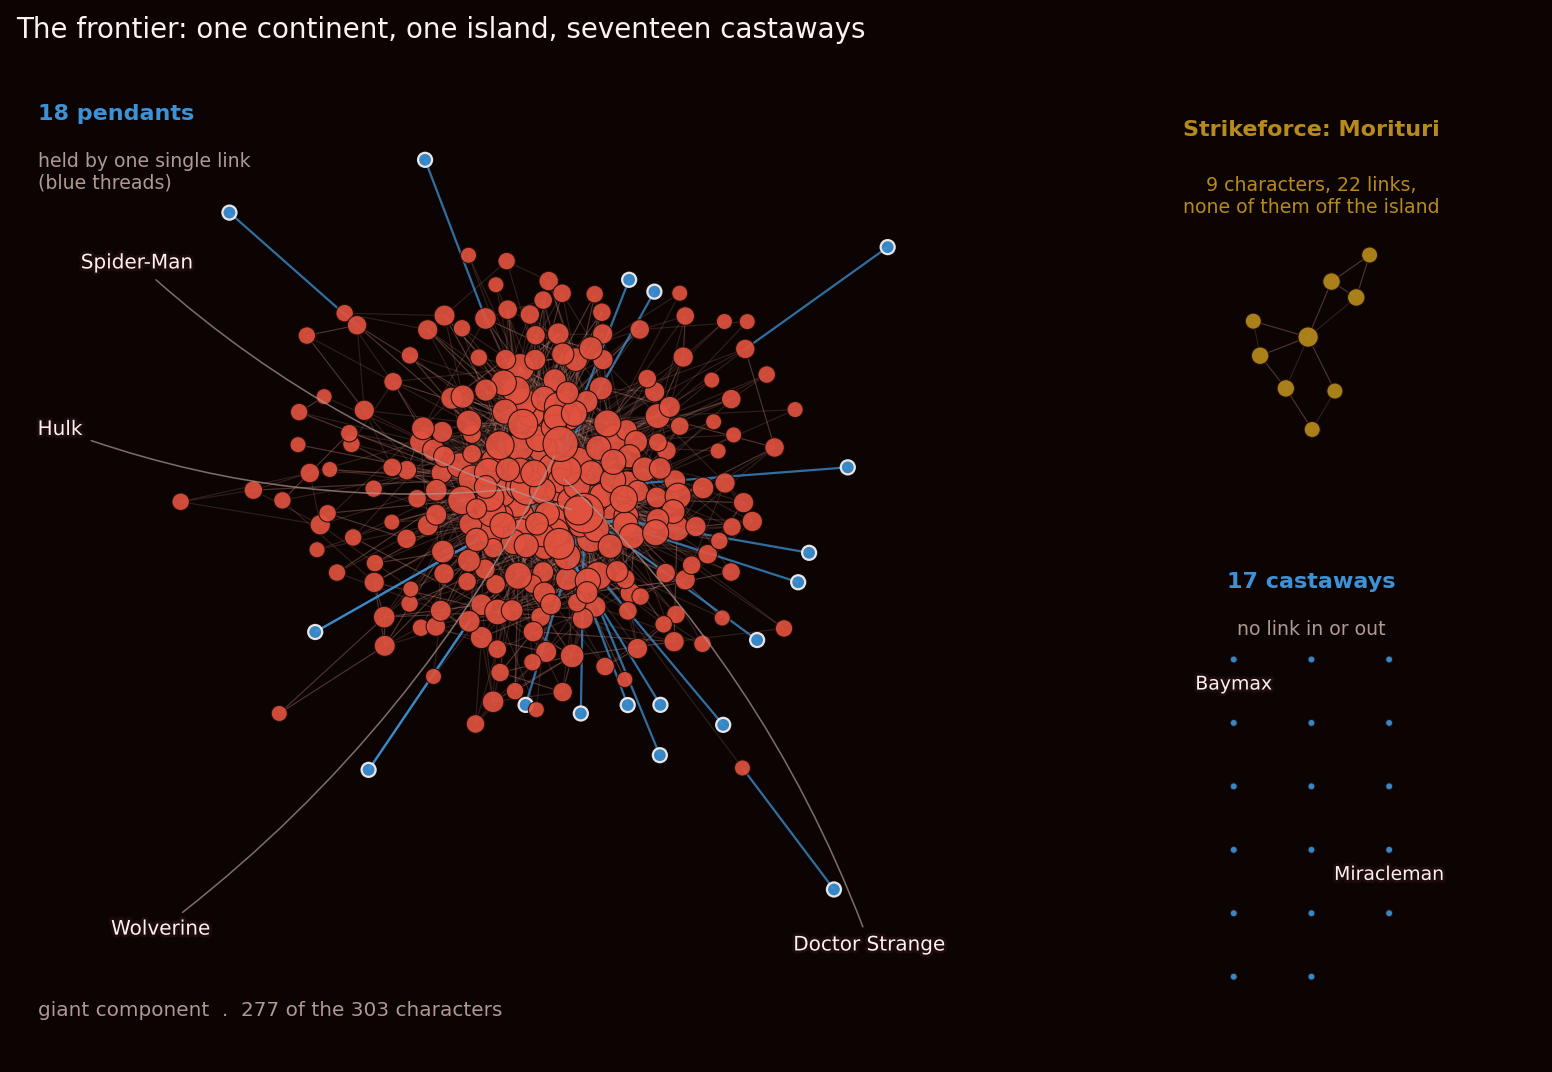

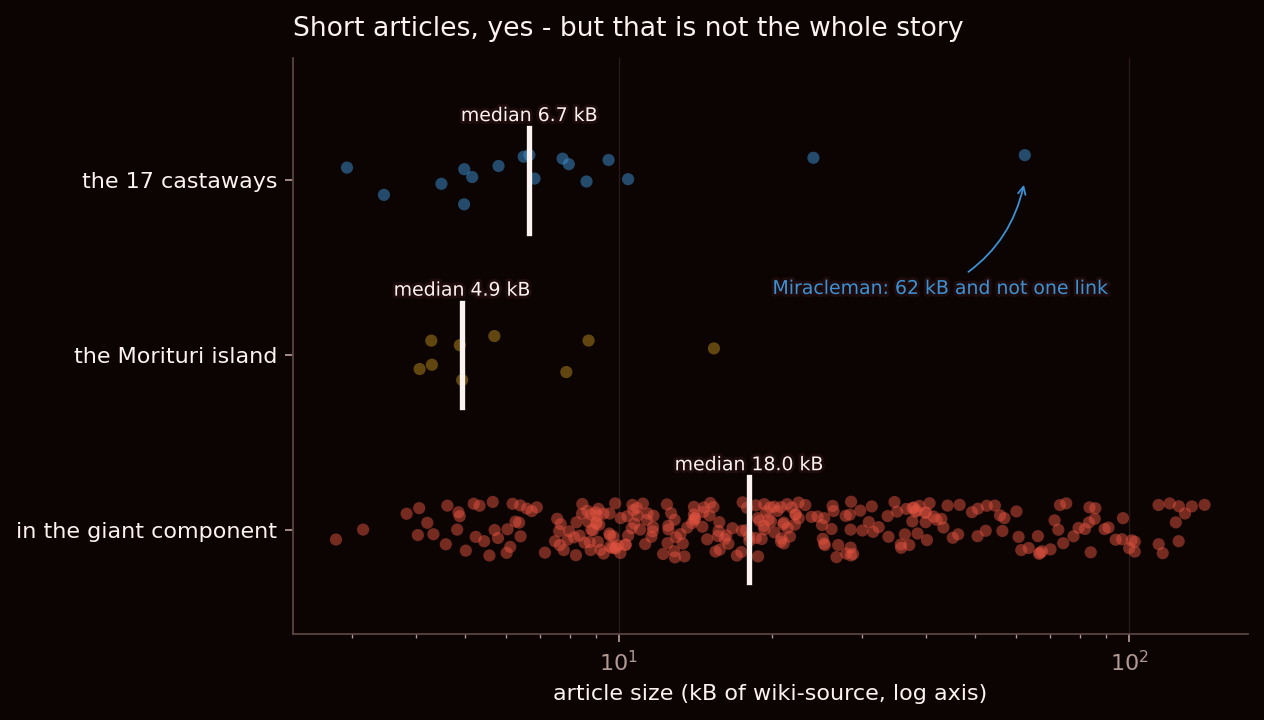

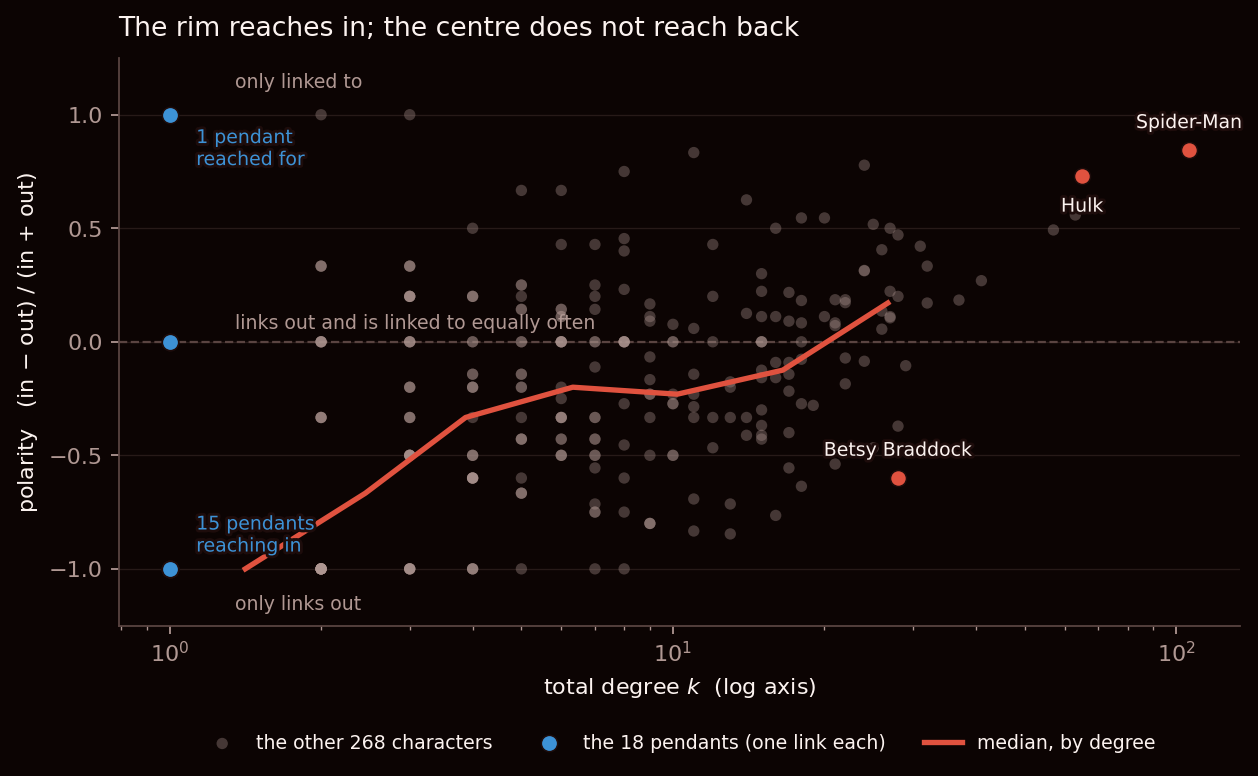

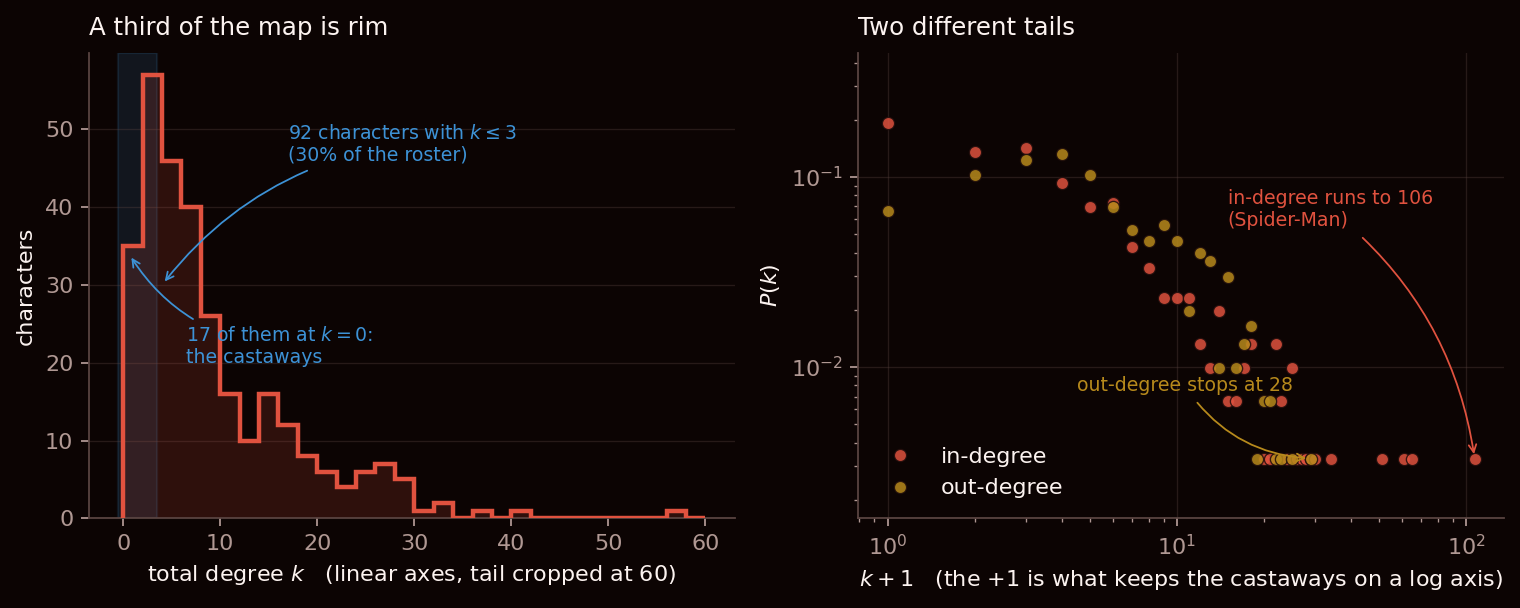

In [12]:
from IPython.display import Image, display
import os

for name in ("week1_frontier_map", "week1_article_size",
             "week1_polarity", "week1_degree_distributions"):
    display(Image(filename=os.path.join(A.IMG, name + ".png")))

## Caveats

- This is a network of **articles**, not of characters. An edge means an editor wrote a
  link, which tracks fame, article length and editorial habit as much as the stories.
- Every "0" above means "no link to another page **inside this 303-character
  category**". Those articles link to plenty of Marvel pages that are not superheroes.
- The four-way split of the castaways is our reading of seventeen opening sentences,
  not a measurement.
- ρ = 0.82 between size and degree is a correlation with no direction attached.
- Polarity is undefined for the castaways (0/0), so they are absent from Fig. 3 by
  construction.

**Reproduce:** `python analysis_week1.py --wiki` (once, to fill the API cache), then
`python analysis_week1.py`. The API calls send a `User-Agent` naming the client —
Wikipedia answers 403 without one — and back off on 429.